In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("diabetes.csv",dtype={"Outcome":bool})

In [55]:
print("shape:",df.shape)
print("\ncolumns:",df.columns.to_list())
print("\nDatatypes:")
print(df.dtypes) 
print("Sample Records:\n")
print(df.head())

shape: (392, 9)

columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Datatypes:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                        bool
dtype: object
Sample Records:

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
3             1       89             66             23       94  28.1   
4             0      137             40             35      168  43.1   
6             3       78             50             32       88  31.0   
8             2      197             70             45      543  30.5   
13            1      189             60             23      846  30.1   

    DiabetesPedigreeFunction  Age  Outcome 

In [3]:
print("Numerical Variables:")
print([
    "Pregnancies", "Glucose", "BloodPressure",
    "SkinThickness", "Insulin", "BMI",
    "DiabetesPedigreeFunction", "Age"
])

print("\nBinary Variable:")
print("Outcome")

Numerical Variables:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Binary Variable:
Outcome


In [4]:
print(df.describe())
print("\nVariance:")
print(df.var())

print("\nMedian:")
print(df.median())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  768.000000                768.000000  768.000000  
mean    31.992578                  0.471876   33.240885  
std      7.884160                  0.331329   11.760232  
min      0.000000                  0.078000   21.000000  
25%     27.300000        

In [32]:
print("Missing Values:")
print(df.isnull().sum())
#but p is invalid value for Glucose, BloodPressure,skin thickness, Insulin, BMI
invalid_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print("\nInvalid Zero Values:")
print((df[invalid_columns]==0).sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Invalid Zero Values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [63]:
print("Outliers using IQR\n")
for col in df.columns[:-1]:      # Skip Outcome
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Outliers using IQR

Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


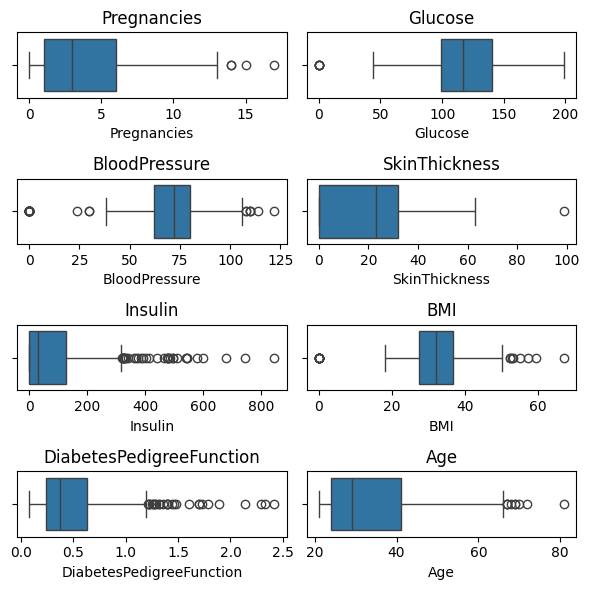

In [88]:
fig, axes = plt.subplots(4,2, figsize=(6, 6))

for ax, col in zip(axes.flatten(), df.columns[:-1]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

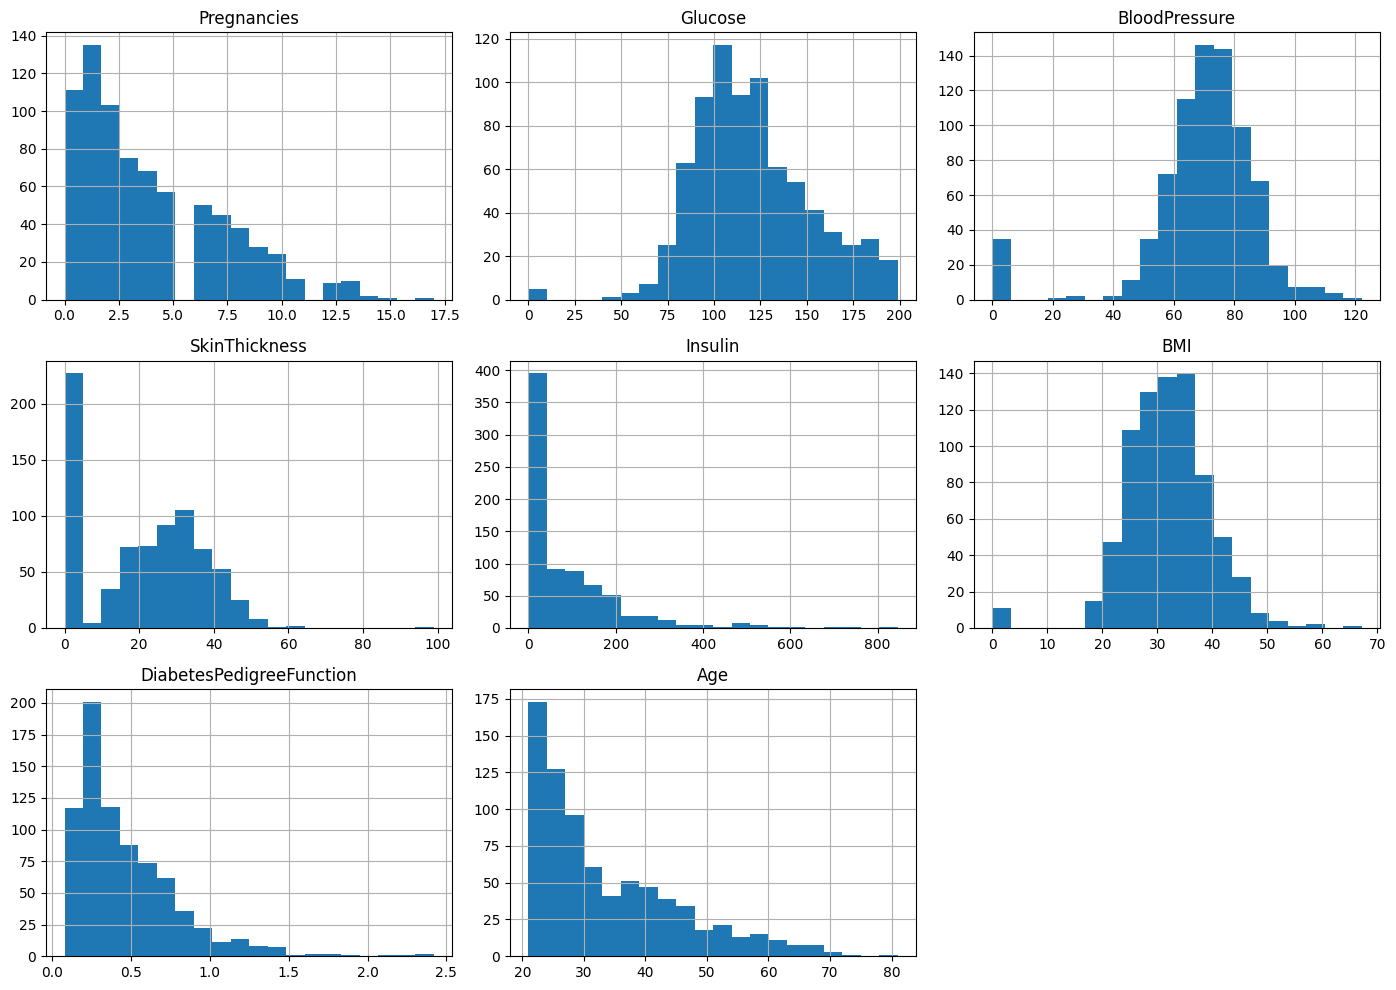

In [100]:
df.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

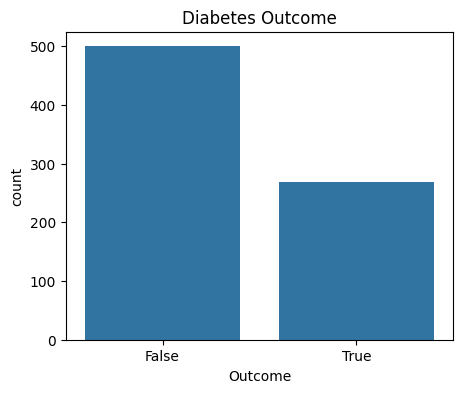

In [91]:
plt.figure(figsize=(5,4))
sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome")
plt.show()

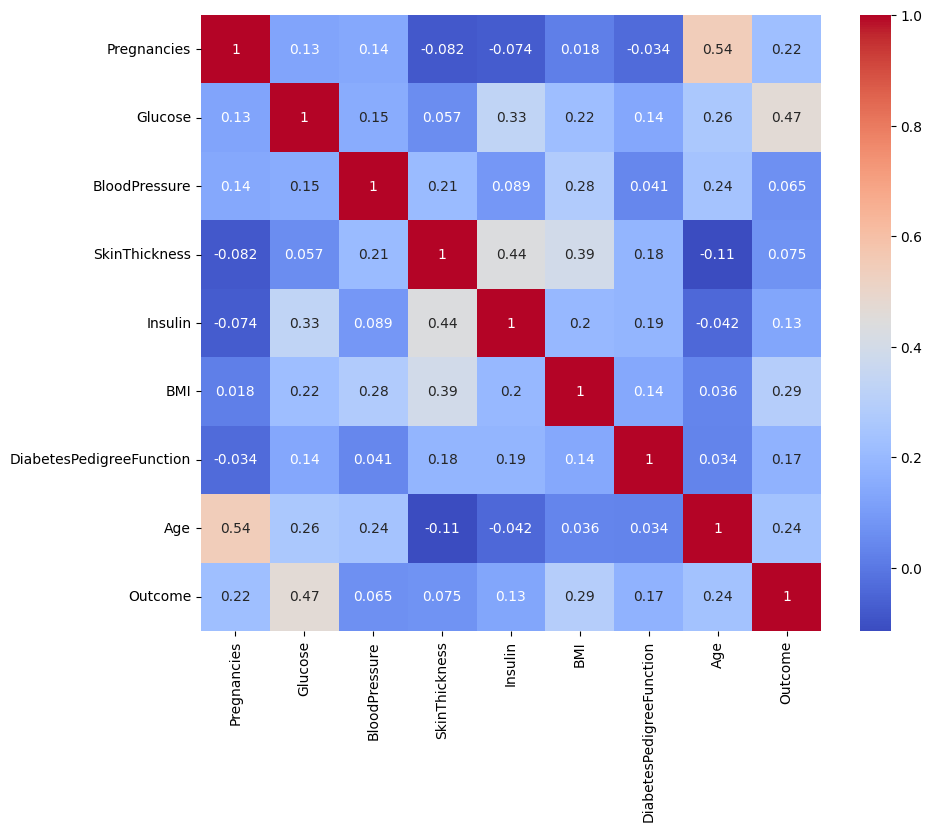

In [114]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

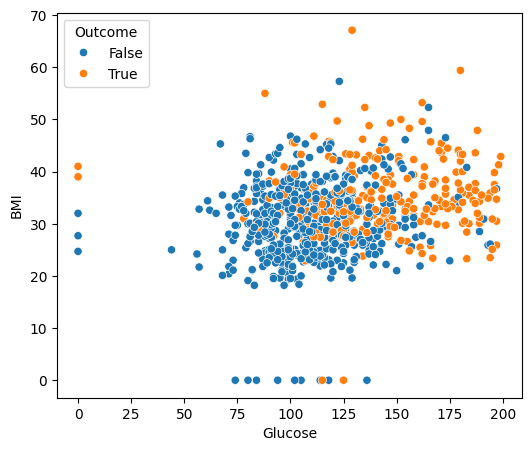

In [112]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Glucose",
    y="BMI",
    hue="Outcome",
    data=df
)

plt.show()

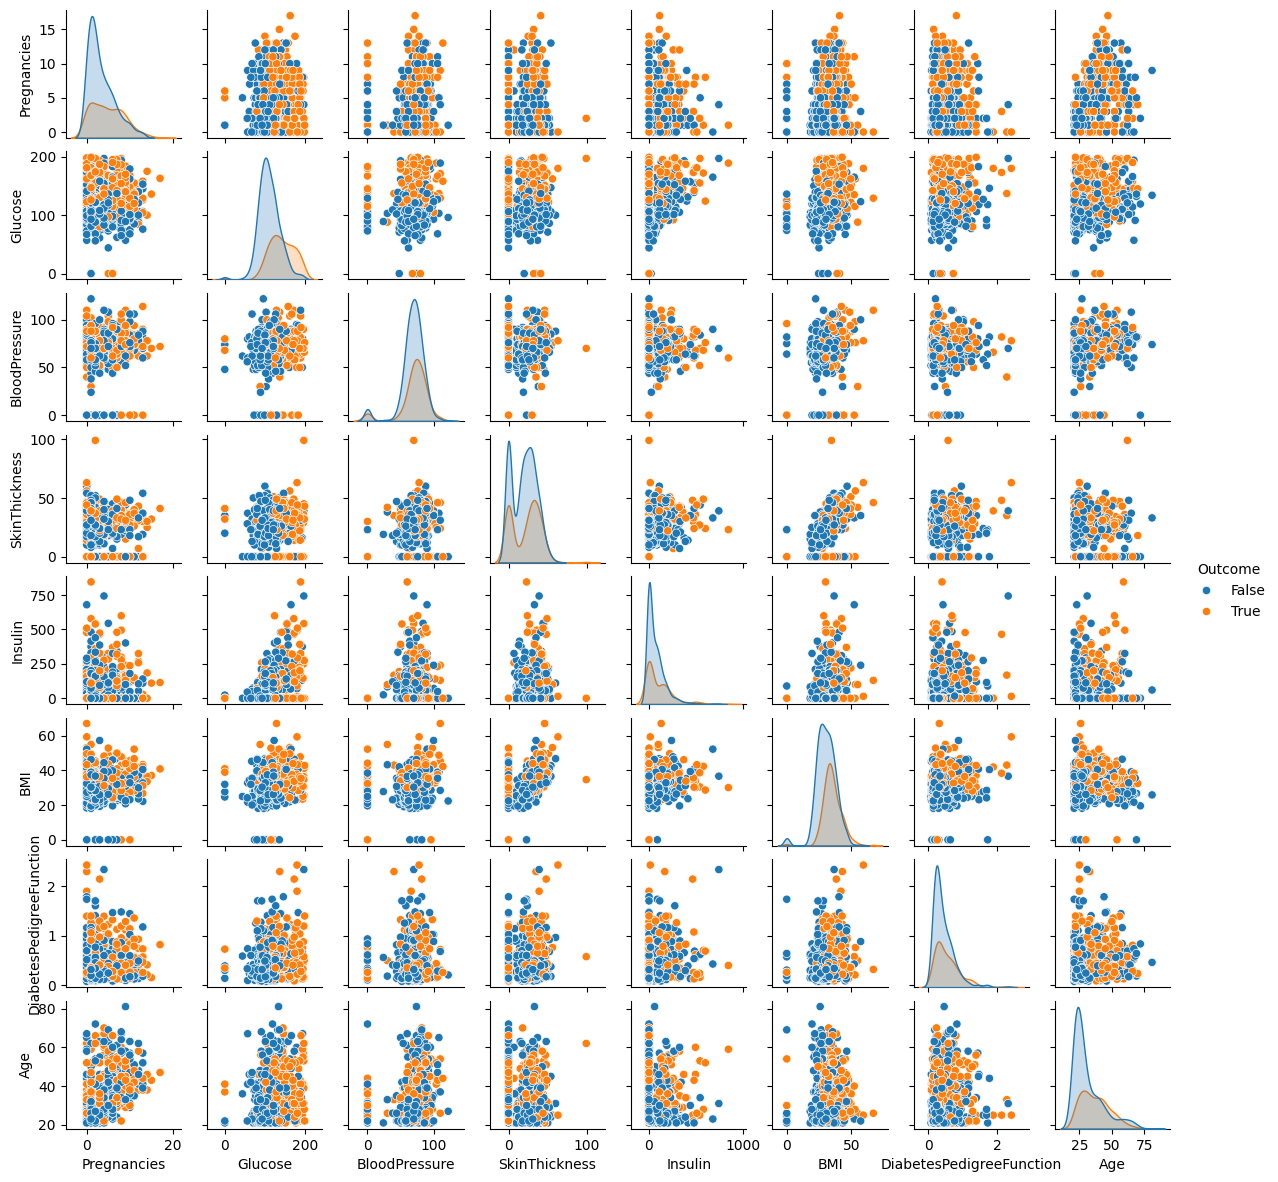

In [123]:
sns.pairplot(df, hue="Outcome",height=1.5)
plt.show()

In [125]:
print("Dataset Shape:", df.shape)

print("\nInvalid Zero Values:")
print((df[invalid_columns]==0).sum())

print("\nOutcome Distribution")
print(df["Outcome"].value_counts())

Dataset Shape: (768, 9)

Invalid Zero Values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Outcome Distribution
Outcome
False    500
True     268
Name: count, dtype: int64
